# Μέρος 3: Συνένωση Εικόνων (Image Stitching) για Δημιουργία Πανοράματος

# Βήμα 0: Διάβασμα εικόνων

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Load first 2 images
image1 = cv2.imread('part3_data/img1a_ratio05.jpg')
image2 = cv2.imread('part3_data/img1b_ratio05.jpg')

## Βήμα 1: Εντοπισμός χαρακτηριστικών ενδιαφέροντος και εξαγωγή περιγραφητών

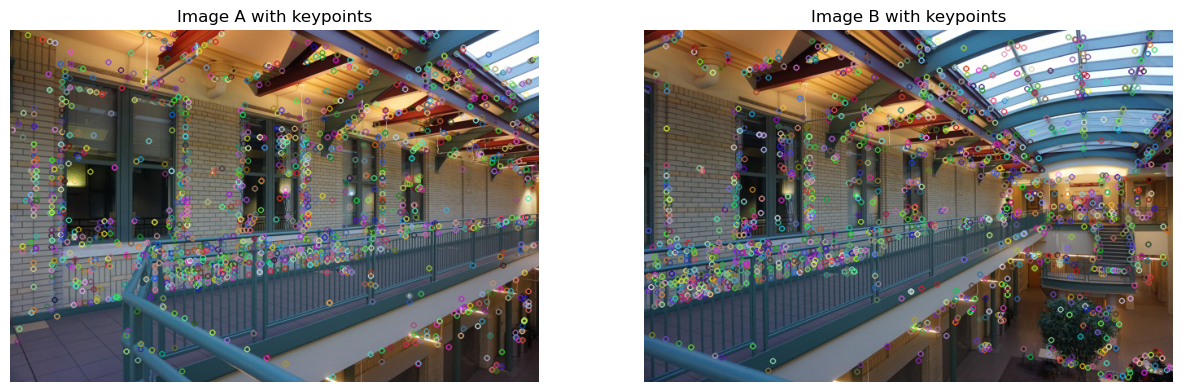

In [3]:
# Detect SIFT keypoints and descriptors in the images
sift = cv2.xfeatures2d.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
image1_keypoints = cv2.drawKeypoints(image1, keypoints1, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2, None)
image2_keypoints = cv2.drawKeypoints(image2, keypoints2, None)

# Display results
image1_keypoints = cv2.cvtColor(image1_keypoints, cv2.COLOR_BGR2RGB)
image2_keypoints = cv2.cvtColor(image2_keypoints, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.subplot(121), plt.imshow(image1_keypoints)
plt.title('Image A with keypoints'), plt.axis('off')
plt.subplot(122), plt.imshow(image2_keypoints)
plt.title('Image B with keypoints'), plt.axis('off')
plt.show()

## Βήμα 2: Διαδικασία ταιριάσματος χαρακτηριστικών μεταξύ δύο εικόνων

In [4]:
# Find 2 matches for each keaypoint of image 1
FL1NN_INDEX_KDTREE = 0
index_params = dict(algorithm = FL1NN_INDEX_KDTREE, trees = 5)
search_params = {}

flann = cv2.FlannBasedMatcher(index_params,search_params)

matches = flann.knnMatch(descriptors1, descriptors2, k=2)

## Βήμα 3: Διατήρηση μόνο των πιο έγκυρων αντιστοιχίσεων μέσω εφαρμογής του κριτηρίου Lowe

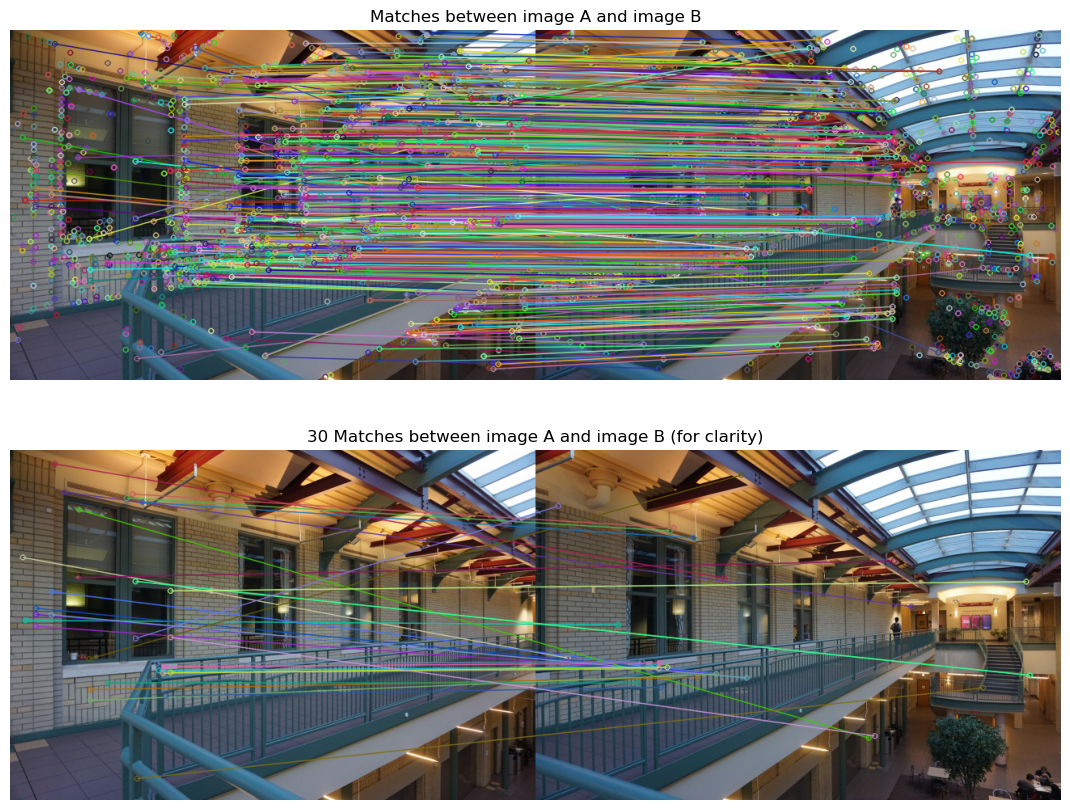

In [5]:
# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < n.distance * 0.8:
        good_matches.append(m)

# Draw matches
image_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches, None)
image_matches = cv2.cvtColor(image_matches, cv2.COLOR_BGR2RGB)
clean_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches[:30], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
clean_matches = cv2.cvtColor(clean_matches, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
plt.imshow(image_matches)
plt.axis('off')
plt.title('Matches between image A and image B')
plt.subplot(2,1,2)
plt.imshow(clean_matches)
plt.axis('off')
plt.title('30 Matches between image A and image B (for clarity)')
plt.show()

# Βήμα 4: Υπολογισμός ομογραφίας με RANSAC

In [6]:
# For each keypoint match, get the coordinates of the keypoint
srcPoints = [keypoints1[m.queryIdx].pt for m in good_matches]
srcPoints = np.array(srcPoints).reshape(-1, 1, 2)
dstPoints = [keypoints2[m.trainIdx].pt for m in good_matches]
dstPoints = np.array(dstPoints).reshape(-1, 1, 2)

# Find homography
threshold = 3.0 # between 1.0 and 10.0
H, mask = cv2.findHomography(srcPoints, dstPoints, cv2.RANSAC, threshold)
H

array([[ 1.64714350e+00,  4.07862047e-03, -3.22165269e+02],
       [ 2.06681765e-01,  1.39119214e+00, -7.84662692e+01],
       [ 1.00236580e-03, -1.87165180e-05,  1.00000000e+00]])

## Βήμα 5: Υπολογισμός μετασχηματισμένης εικόνας μέσω εφαρμογής Inverse warping

Top left coordinates of warped image: [-323.01703  -78.46627]


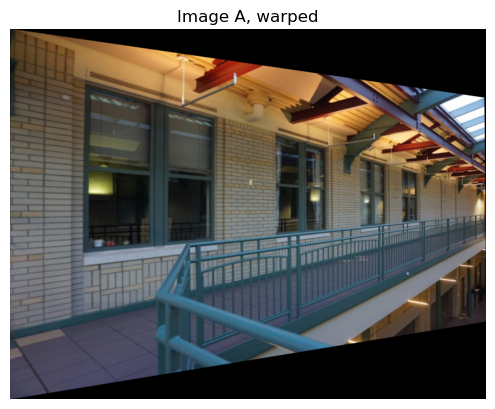

In [13]:
def projectionImage(H, image):
    h, w, _ = image.shape

    # Calculate the warped corners of the image
    corners = np.array([[0, 0], [0, h], [w, h], [w, 0]], dtype=np.float32)
    corners = corners.reshape(-1, 1, 2) # Required by perspectiveTransform()
    warped_corners = cv2.perspectiveTransform(corners, H)
    warped_corners = warped_corners.reshape(4,2)
    topleft_coords = warped_corners.min(axis=0)
    bottomright_coords = warped_corners.max(axis=0)

    # Calculate translation needed to shift the image to the origin
    T = np.array([[1, 0, -topleft_coords[0]],
                  [0, 1, -topleft_coords[1]],
                  [0, 0, 1]], dtype=np.float32)
    
    # Calculate warped image
    warped_width = int(bottomright_coords[0] - topleft_coords[0])
    warped_height = int(bottomright_coords[1] - topleft_coords[1])
    img_warped = cv2.warpPerspective(image, T.dot(H), (warped_width, warped_height))

    return img_warped, topleft_coords
img1_warped, topleft_coords = projectionImage(H, image1)

# Display the warped image
plt.title('Image A, warped')
plt.imshow(cv2.cvtColor(img1_warped, cv2.COLOR_BGR2RGB))
plt.axis('off')

print(f"Top left coordinates of warped image: {topleft_coords}")

## Βήμα 6: Συνένωση των εικόνων

Text(0.5, 1.0, 'Stitched image')

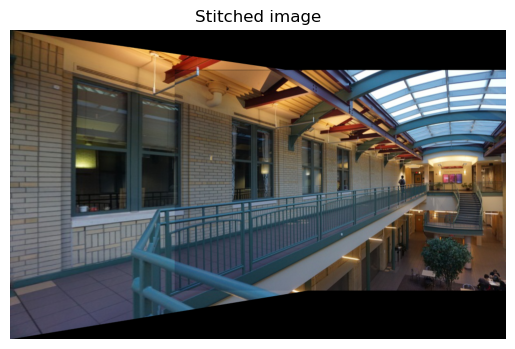

In [8]:
def mergeWarpedImages(img1_warped, img2, img1_topleft_coords):
    # Image 2: top left corner at origin and leave space for image1
    h, w, _ = img2.shape
    new_width = w + abs(int(img1_topleft_coords[0]))
    new_height = h + abs(int(img1_topleft_coords[1]))
    T = np.array(([[1, 0, -img1_topleft_coords[0]],
                   [0, 1, -img1_topleft_coords[1]],
                   [0, 0, 1]]), dtype=np.float32)
    img2_warped = cv2.warpPerspective(img2,T,(new_width, new_height))

    # Resize finale images
    final_width = max(img1_warped.shape[1], img2_warped.shape[1])
    final_height = max(img1_warped.shape[0], img2_warped.shape[0])
    img1_final = cv2.warpPerspective(img1_warped,np.identity(3),(final_width,final_height))
    img2_final = cv2.warpPerspective(img2_warped,np.identity(3),(final_width,final_height))
    
    # Delete overlapping pixels from img1
    img1_final[img2_final>0] = 0

    return img1_final + img2_final

stitched_image = mergeWarpedImages(img1_warped, image2, topleft_coords)
plt.imshow(cv2.cvtColor(stitched_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Stitched image')

## Τελικό Βήμα: Δημιουργία Πανοραμικής Φωτογραφίας

In [9]:
def stitchImages(img1, img2):
    # Detect SIFT keypoints and descriptors in the images
    sift = cv2.xfeatures2d.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

    # Find 2 matches for each keaypoint of image 1
    FL1NN_INDEX_KDTREE = 0
    index_params = dict(algorithm = FL1NN_INDEX_KDTREE, trees = 5)
    search_params = {}
    flann = cv2.FlannBasedMatcher(index_params,search_params)
    matches = flann.knnMatch(descriptors1, descriptors2, k=2)

    # Apply Lowe's ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < n.distance * 0.8:
            good_matches.append(m)
    
    # For each keypoint match, get the coordinates of the keypoint
    srcPoints = [keypoints1[m.queryIdx].pt for m in good_matches]
    srcPoints = np.array(srcPoints).reshape(-1, 1, 2)
    dstPoints = [keypoints2[m.trainIdx].pt for m in good_matches]
    dstPoints = np.array(dstPoints).reshape(-1, 1, 2)

    # Find homography
    threshold = 3.0 # between 1.0 and 10.0
    H, mask = cv2.findHomography(srcPoints, dstPoints, cv2.RANSAC, threshold)

    # Warp image 1
    img1_warped, topleft_coords = projectionImage(H, img1)

    # Return stitched warped images
    return mergeWarpedImages(img1_warped, img2, topleft_coords)

def panorama(images):
    # Gets a list of images, returns the stitched panoramic image
    # Works only for horizontal panoramas

    images = images.copy()
    print("Images to stitch:", len(images))

    if len(images) == 1:
        return images[0]
    if len(images) == 2:
        return stitchImages(images[0], images[1])
    return stitchImages(panorama(images[:len(images)//2]), panorama(images[len(images)//2:]))

In [10]:
# Load all images
filenames = ["img1a_ratio05.jpg", "img1b_ratio05.jpg", "img2_ratio05.jpg", "img3a_ratio05.jpg", "img3b_ratio05.jpg", "img4_ratio05.jpg", "img5_ratio05.jpg", "img6_ratio05.jpg"]
# filenames = ["img1a_ratio05.jpg", "img1b_ratio05.jpg", "img2_ratio05.jpg", "img3a_ratio05.jpg", "img3b_ratio05.jpg"]
images = [cv2.imread(f"part3_data/{filename}") for filename in filenames]

Text(0.5, 1.0, 'Panoramic Image (top row)')

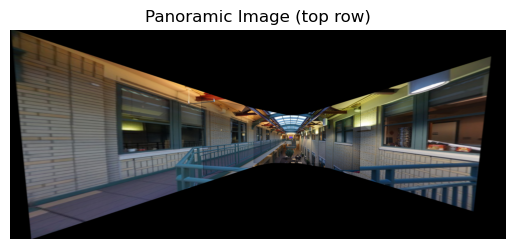

In [11]:
# Make Panoramic Image (top row)
image12 = stitchImages(images[0], images[1])
image23 = stitchImages(images[1], images[2])
image43 = stitchImages(images[3], images[2])
image54 = stitchImages(images[4], images[3])

image123 = stitchImages(image12, image23)
image543 = stitchImages(image54, image43)

panoramic_image_top = stitchImages(image123, image543)

# Display Panoramic Image
plt.imshow(cv2.cvtColor(panoramic_image_top, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Panoramic Image (top row)')